(13)=
# Chapter 13: Statistics & Random Sampling & Distributions

**Topics Covered:**
- Descriptive statistics: mean, median, variance, standard deviation, percentiles
- Random number generation with `numpy.random`
- Key probability distributions: uniform, normal, exponential, Poisson
- The Central Limit Theorem and why it matters in engineering
- Confidence intervals and hypothesis testing basics

In [8]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

**Motivation: Why Statistics in Chemical Engineering?**

Real engineering data is **never perfect**. Thermocouples drift. Flow meters have noise. Reaction yields vary batch to batch. Laboratory measurements have inherent uncertainty.

Statistics gives us the tools to:
1. **Summarize** data concisely (what is "typical"? how much does it vary?)
2. **Quantify uncertainty** in measured quantities
3. **Make decisions** despite noisy data (is the process on-target? is a new catalyst better?)
4. **Propagate uncertainty** through calculations (if my temperature measurement is off by 2 K, how much does that affect my computed rate constant?)

These aren't just academic exercises. Regulatory agencies (FDA, EPA) require statistical justification for process specifications. Process engineers use statistics daily for quality control, troubleshooting, and design of experiments.

---

Consider a batch reactor producing a pharmaceutical intermediate. The target yield is 88%. You run 15 batches and get:

```
85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0
```

Questions you need to answer:
- What is the average yield, and how much does it vary?
- Is the process meeting the 88% target **on average**?
- What fraction of future batches will fall below the 85% lower limit?
- How many measurements do you need to estimate the mean within ±0.5%?

All of these require statistics.

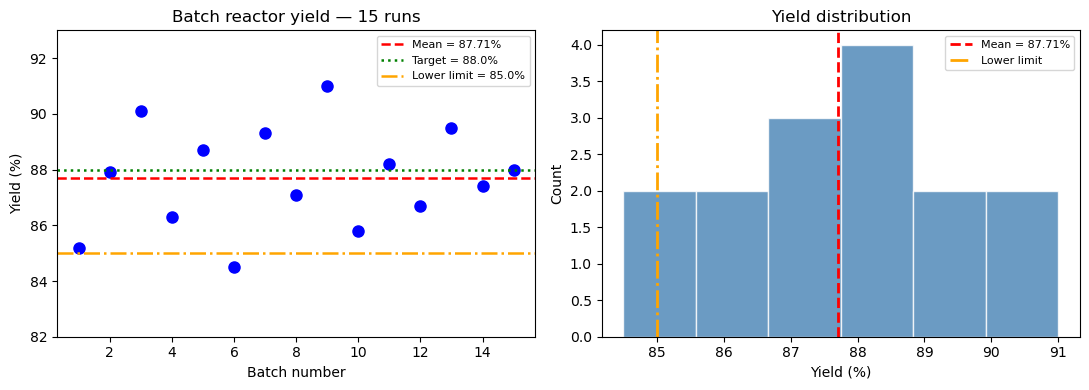

Number of batches  : 15
Mean yield         : 87.71%
Batches below 85%  : 1


In [9]:
# Batch reactor yield data (% yield)
yields = np.array([85.2, 87.9, 90.1, 86.3, 88.7, 84.5, 89.3, 87.1,
                   91.0, 85.8, 88.2, 86.7, 89.5, 87.4, 88.0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw data as a dot plot
ax = axes[0]
ax.plot(range(1, len(yields)+1), yields, 'bo', markersize=8)
ax.axhline(np.mean(yields), color='red',    linestyle='--', linewidth=1.8, label=f'Mean = {np.mean(yields):.2f}%')
ax.axhline(88.0,             color='green', linestyle=':',  linewidth=1.8, label='Target = 88.0%')
ax.axhline(85.0,             color='orange',linestyle='-.',  linewidth=1.8, label='Lower limit = 85.0%')
ax.set_xlabel('Batch number')
ax.set_ylabel('Yield (%)')
ax.set_title('Batch reactor yield — 15 runs')
ax.legend(fontsize=8)
ax.set_ylim(82, 93)

# Right: histogram
ax = axes[1]
ax.hist(yields, bins=6, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(yields), color='red',    linestyle='--', linewidth=2, label=f'Mean = {np.mean(yields):.2f}%')
ax.axvline(85.0,             color='orange', linestyle='-.', linewidth=2, label='Lower limit')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Count')
ax.set_title('Yield distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Number of batches  : {len(yields)}")
print(f"Mean yield         : {np.mean(yields):.2f}%")
print(f"Batches below 85%  : {np.sum(yields < 85.0)}")

(13.1)=
## 13.1 Descriptive Statistics

**Descriptive statistics** summarize the key properties of a dataset with a few numbers. Instead of reporting all 15 yield values, we report "mean 87.7%, std 1.8%" — much more useful.

There are two kinds of summary:
- **Measures of location** — where is the center of the data?
- **Measures of spread** — how much does the data vary around that center?

### Measures of location (center)

$$
\text{Mean:}\quad \bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i
\qquad\qquad
\text{Median:}\quad \text{middle value when sorted}
$$

- **Mean** is the arithmetic average — sensitive to outliers (a single extreme batch can pull it significantly)
- **Median** is the middle value — robust to outliers, better for skewed data
- For symmetric, unimodal data the two are approximately equal. A large difference between mean and median signals **skewness**.

> **ChE example:** If one batch had a catastrophic yield of 30% (contamination event), the mean would drop significantly but the median would barely move. The median better represents "typical" performance.

### Measures of spread

$$
\text{Variance:}\quad s^2 = \frac{1}{N-1}\sum_{i=1}^{N}(x_i - \bar{x})^2
\qquad\qquad
\text{Std dev:}\quad s = \sqrt{s^2}
$$

- **Variance** $s^2$ measures average squared deviation from the mean. Squaring penalizes large deviations more than small ones.
- **Standard deviation** $s$ is in the same units as the data (e.g., %), making it more interpretable.
- The **$N-1$** denominator (Bessel's correction) gives an unbiased estimate of the population variance from a sample — more on this below.

### Percentiles

The **$q$-th percentile** is the value below which $q\%$ of the data falls.
- 25th percentile = Q1 (first quartile)
- 50th percentile = Q2 = median
- 75th percentile = Q3 (third quartile)
- **Interquartile range (IQR)** = Q3 − Q1: the spread of the middle 50% of data, robust to outliers

> **ChE use:** Percentiles directly answer questions like "What yield is guaranteed 90% of the time?" This is more actionable than mean ± std for decision-making.

| Statistic | NumPy function | Notes |
|-----------|---------------|-------|
| Mean | `np.mean(x)` | Arithmetic average |
| Median | `np.median(x)` | 50th percentile |
| Variance | `np.var(x)` | `ddof=1` → sample variance (÷ N−1) |
| Std dev | `np.std(x)` | `ddof=1` → sample std dev |
| Min/Max | `np.min(x)`, `np.max(x)` | Extremes |
| Percentile | `np.percentile(x, q)` | $q$-th percentile |
| Range | `np.ptp(x)` | max − min |

**`ddof` (delta degrees of freedom):** By default NumPy uses `ddof=0` (divides by $N$), which gives the **population** variance. For a **sample** drawn from a larger population, always use `ddof=1` (divides by $N-1$) to get an unbiased estimate.

In [ ]:
# ── Descriptive statistics on the yield data ──────────────────────────────────
# Each line below answers a specific engineering question about the batch process.
print("Descriptive statistics for batch yield data")
print("-" * 45)
print(f"  N                 : {len(yields)}")
print(f"  Mean              : {np.mean(yields):.4f} %")       # best estimate of the true mean yield
print(f"  Median            : {np.median(yields):.4f} %")     # middle value — compare to mean
print(f"  Std dev (sample)  : {np.std(yields, ddof=1):.4f} %")  # typical deviation from mean
print(f"  Variance (sample) : {np.var(yields, ddof=1):.4f} %²") # std² — less intuitive but used in formulas
print(f"  Min               : {np.min(yields):.1f} %")
print(f"  Max               : {np.max(yields):.1f} %")
print(f"  Range             : {np.ptp(yields):.1f} %")        # max - min
print(f"  10th percentile   : {np.percentile(yields, 10):.2f} %")  # 10% of batches fall below this
print(f"  25th percentile   : {np.percentile(yields, 25):.2f} %  (Q1)")
print(f"  75th percentile   : {np.percentile(yields, 75):.2f} %  (Q3)")
print(f"  IQR               : {np.percentile(yields, 75) - np.percentile(yields, 25):.2f} %")

print()
print("Interpretation:")
print(f"  Mean ({np.mean(yields):.2f}%) vs Median ({np.median(yields):.2f}%) — very close,")
print(f"  suggesting a roughly symmetric distribution (no major outliers).")
print(f"  The 10th percentile ({np.percentile(yields, 10):.2f}%) tells us 10% of batches")
print(f"  will fall below this value — useful for setting lower spec limits.")

### Why `ddof=1`? Bessel's Correction

This is a subtle but important point. When we compute the variance from a **sample**, we use the sample mean $\bar{x}$ rather than the true population mean $\mu$. This introduces a systematic bias.

**Intuition:** The sample mean $\bar{x}$ is chosen to minimize the sum of squared deviations from the data — it is "closer" to the data points than the true mean $\mu$ would be. This means the deviations $(x_i - \bar{x})$ tend to be *smaller* than the true deviations $(x_i - \mu)$. Dividing by $N-1$ instead of $N$ corrects for this systematic underestimation.

**Mathematically**, the correction ensures the sample variance is an *unbiased* estimator:

$$
s^2 = \frac{1}{N-1}\sum(x_i - \bar{x})^2
\quad \Rightarrow \quad \mathbb{E}[s^2] = \sigma^2
$$

We say we "use up" one degree of freedom by estimating the mean, leaving $N-1$ free to estimate the variance.

The effect is small for large $N$ but significant for small samples:
- $N = 5$: dividing by 4 vs 5 → **25% difference**
- $N = 10$: dividing by 9 vs 10 → **11% difference**
- $N = 100$: dividing by 99 vs 100 → **1% difference**

**Rule:** Always use `ddof=1` when working with sample data from an experiment. Only use `ddof=0` when you have the *entire* population (e.g., when you simulate all possible outcomes).

In [5]:
# ── Population vs sample variance ────────────────────────────────────────────
print("Effect of ddof on variance estimate")
print(f"  np.var(yields, ddof=0)  = {np.var(yields, ddof=0):.4f}  (population / divides by N)")
print(f"  np.var(yields, ddof=1)  = {np.var(yields, ddof=1):.4f}  (sample    / divides by N-1)")
print()
print("Manual check:")
N = len(yields)
mean_y = np.mean(yields)
ss = np.sum((yields - mean_y)**2)
print(f"  Sum of squares SS       = {ss:.4f}")
print(f"  SS / N                  = {ss/N:.4f}")
print(f"  SS / (N-1)              = {ss/(N-1):.4f}")

Effect of ddof on variance estimate
  np.var(yields, ddof=0)  = 3.1558  (population / divides by N)
  np.var(yields, ddof=1)  = 3.3812  (sample    / divides by N-1)

Manual check:
  Sum of squares SS       = 47.3373
  SS / N                  = 3.1558
  SS / (N-1)              = 3.3812


### Using `scipy.stats.describe`

`scipy.stats` provides a convenience function `describe()` that returns all basic statistics in one call.

In [4]:
# ── scipy.stats.describe ──────────────────────────────────────────────────────
desc = stats.describe(yields)
print(f"nobs     : {desc.nobs}")
print(f"min/max  : {desc.minmax}")
print(f"mean     : {desc.mean:.4f}")
print(f"variance : {desc.variance:.4f}   (uses ddof=1)")
print(f"skewness : {desc.skewness:.4f}   (0 = symmetric)")
print(f"kurtosis : {desc.kurtosis:.4f}   (0 = normal tail weight)")

nobs     : 15
min/max  : (84.5, 91.0)
mean     : 87.7133
variance : 3.3812   (uses ddof=1)
skewness : -0.0034   (0 = symmetric)
kurtosis : -0.7790   (0 = normal tail weight)


(13.2)=
## 13.2 Random Number Generation

Many statistical tools require drawing **random samples** — either to simulate a process, test a hypothesis, or propagate uncertainty. NumPy's `numpy.random` module generates **pseudo-random** numbers: deterministic sequences that are statistically indistinguishable from true randomness.

**Why pseudo-random (not truly random)?** True randomness requires physical processes (radioactive decay, thermal noise). Pseudo-random generators use deterministic algorithms that produce sequences with excellent statistical properties. For engineering simulations, this is perfectly sufficient.

### Setting a seed

The pseudo-random generator starts from an initial state called the **seed**. Same seed → same sequence every time. This is critical for:
- **Reproducibility**: someone else runs your code and gets identical results
- **Debugging**: you can reproduce a specific run that showed unexpected behavior
- **Collaboration**: results in your notebook exactly match results in a report

```python
rng = np.random.default_rng(seed=42)   # recommended modern API

np.random.seed(42) # legacy approach 
```

Always set a seed at the top of any simulation notebook.

### Key generation functions

| Function | Distribution | Parameters |
|--------------------|-------------|------------|
| `rng.random(n)` | Uniform [0, 1) | — |
| `rng.uniform(low, high, n)` | Uniform [low, high) | low, high |
| `rng.normal(mu, sigma, n)` | Normal (Gaussian) | mean $\mu$, std $\sigma$ |
| `rng.exponential(scale, n)` | Exponential | mean = `scale` = $1/\lambda$ |
| `rng.integers(low, high, n)` | Discrete uniform | integer range |
| `rng.choice(a, n)` | Random selection | array `a` |
| `rng.shuffle(a)` | Shuffle in-place | array `a` |


or 

| Function | Distribution | Parameters |
|--------------------|-------------|------------|
| `np.random.random(n)` | Uniform [0, 1) | — |
| `np.random.uniform(low, high, n)` | Uniform [low, high) | low, high |
| `np.random.normal(mu, sigma, n)` | Normal (Gaussian) | mean $\mu$, std $\sigma$ |
| `np.random.exponential(scale, n)` | Exponential | mean = `scale` = $1/\lambda$ |
| `np.random.randint(low, high, n)` | Discrete uniform | integer range |
| `np.random.choice(a, n)` | Random selection | array `a` |
| `np.random.shuffle(a)` | Shuffle in-place | array `a` |

The `size` parameter controls the shape of the output — pass a single integer for 1-D arrays, or a tuple `(rows, cols)` for 2-D arrays.

In [10]:
# ── Basic random number generation ───────────────────────────────────────────
rng = np.random.default_rng(seed=42)

# Uniform [0, 1)
u = rng.random(5)
print("Uniform [0,1):", np.round(u, 4))

# Uniform [a, b)
u2 = rng.uniform(20.0, 30.0, 5)
print("Uniform [20,30):", np.round(u2, 4))

# Normal (Gaussian)
n = rng.normal(loc=0.0, scale=1.0, size=5)
print("Standard Normal:", np.round(n, 4))

# Integers
ints = rng.integers(1, 7, size=10)    # simulates a 6-sided die
print("Dice rolls:     ", ints)

# Random selection
elements = ['H2O', 'CO2', 'CH4', 'N2', 'O2']
choice = rng.choice(elements, size=3, replace=False)
print("Random choice:  ", choice)

Uniform [0,1): [0.774  0.4389 0.8586 0.6974 0.0942]
Uniform [20,30): [29.7562 27.6114 27.8606 21.2811 24.5039]
Standard Normal: [0.8794 0.7778 0.066  1.1272 0.4675]
Dice rolls:      [3 2 1 4 6 1 6 5 2 4]
Random choice:   ['O2' 'H2O' 'N2']


### Reproducibility with seeds

In [11]:
# ── Seed reproducibility demo ─────────────────────────────────────────────────
for trial in range(3):
    rng_test = np.random.default_rng(seed=42)
    x = rng_test.normal(0, 1, 4)
    print(f"Trial {trial+1} (seed=42): {np.round(x, 4)}")

print()
for seed in [0, 1, 42]:
    rng_test = np.random.default_rng(seed=seed)
    x = rng_test.normal(0, 1, 4)
    print(f"seed={seed:>2}: {np.round(x, 4)}")

Trial 1 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 2 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]
Trial 3 (seed=42): [ 0.3047 -1.04    0.7505  0.9406]

seed= 0: [ 0.1257 -0.1321  0.6404  0.1049]
seed= 1: [ 0.3456  0.8216  0.3304 -1.3032]
seed=42: [ 0.3047 -1.04    0.7505  0.9406]


(13.3)=
## 13.3 Probability Distributions

A **probability distribution** is a mathematical model for a random variable. It tells us: "If we draw a value at random, how likely is each possible outcome?"

Choosing the right distribution is one of the most important modeling decisions in statistics. The wrong distribution gives wrong predictions, even with correct data.

Two broad categories:

- **Continuous distributions** — the variable can take any value in a range (temperature, concentration, flow rate, reactor yield)
- **Discrete distributions** — the variable takes only integer values (number of defects, number of events per hour)

### The PDF and CDF

For **continuous distributions**, the **probability density function (PDF)** $f(x)$ describes the relative likelihood of each value. Probabilities are obtained by integrating:

$$
P(a \leq X \leq b) = \int_a^b f(x)\, dx, \qquad \int_{-\infty}^{\infty} f(x)\, dx = 1
$$

Note: $f(x)$ itself is **not** a probability — it is a density. It can exceed 1. Only the area under the curve (integral) gives a probability.

The **cumulative distribution function (CDF)** $F(x)$ gives the probability that $X$ is less than or equal to $x$:

$$
F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t)\, dt
$$

The CDF is always between 0 and 1, and always non-decreasing. In engineering, the CDF directly answers questions like "What fraction of batches will fail the lower spec limit?"

In `scipy.stats`, every distribution object has:
- `.pdf(x)` — evaluate the PDF
- `.cdf(x)` — evaluate the CDF (probability $\leq x$)
- `.ppf(p)` — inverse CDF: find $x$ such that $P(X \leq x) = p$
- `.rvs(size)` — draw random samples

(13.3.1)=
### 13.3.1 Uniform Distribution

Every value in the interval $[a, b]$ is equally likely — the PDF is completely flat.

$$
f(x) = \frac{1}{b - a} \text{ for } a \leq x \leq b
\qquad
\mu = \frac{a+b}{2}
\qquad
\sigma^2 = \frac{(b-a)^2}{12}
$$

**When to use it:** The uniform distribution is appropriate when you know the bounds of uncertainty but have no reason to favor any value within those bounds. It represents **maximum ignorance** within a known range.

**Engineering examples:**
- A flow meter is rated ±2% of full scale (1–100 L/min). If you have no other information about the error distribution, a uniform distribution over the error range is a reasonable default.
- A thermocouple has ±1°C accuracy stated in its spec sheet, but no further calibration data. You might model the true temperature as Uniform(T_read − 1, T_read + 1).
- Rounding errors in digital sensors — if a sensor reports integer °C, the true value is uniformly distributed within ±0.5°C of the reported value.

**scipy.stats parameterization:**
```python
stats.uniform(loc=a, scale=b-a)   # loc = lower bound, scale = width
```

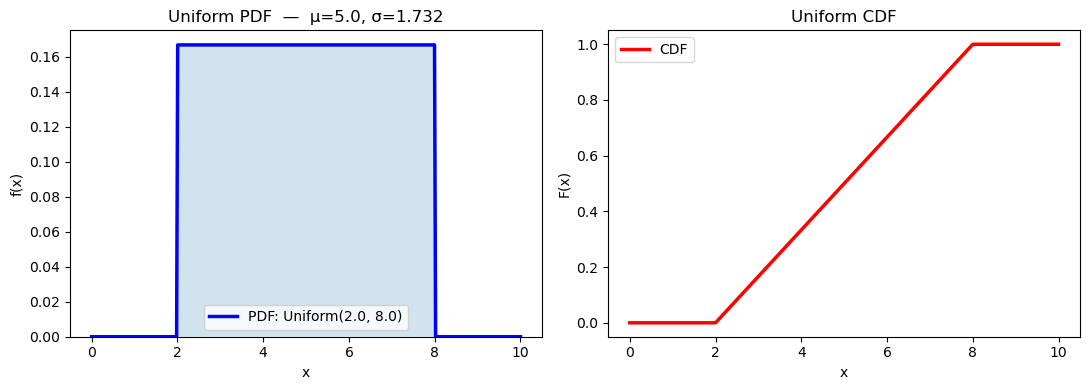

Theoretical  mean = 5.0000,  std = 1.7321
Sample       mean = 4.9935,  std = 1.7449  (n=2000)


In [10]:
# ── Uniform distribution ─────────────────────────────────────────────────────
rng = np.random.default_rng(seed=0)
a, b = 2.0, 8.0

# scipy.stats.uniform: loc=a, scale=(b-a)
dist_u = stats.uniform(loc=a, scale=b - a)

x = np.linspace(0, 10, 400)
samples = rng.uniform(a, b, 2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# PDF + CDF
axes[0].plot(x, dist_u.pdf(x), 'b-', linewidth=2.5, label=f'PDF: Uniform({a}, {b})')
axes[0].fill_between(x, dist_u.pdf(x), alpha=0.2)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Uniform PDF  —  μ={dist_u.mean():.1f}, σ={dist_u.std():.3f}')
axes[0].legend(); axes[0].set_ylim(bottom=0)

axes[1].plot(x, dist_u.cdf(x), 'r-', linewidth=2.5, label='CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].set_title('Uniform CDF'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical  mean = {dist_u.mean():.4f},  std = {dist_u.std():.4f}")
print(f"Sample       mean = {np.mean(samples):.4f},  std = {np.std(samples, ddof=1):.4f}  (n=2000)")

(13.3.2)=
### 13.3.2 Normal (Gaussian) Distribution

The most important distribution in statistics. Symmetric, bell-shaped, described by two parameters: mean $\mu$ and standard deviation $\sigma$.

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

**When to use it:** The normal distribution arises whenever a quantity is the sum or average of many independent random contributions. This is why it appears everywhere:

**Engineering examples:**
- **Measurement error** — a thermocouple reading fluctuates due to electronic noise, vibration, and many other small independent effects. By the Central Limit Theorem (Section 13.5), their sum is normally distributed.
- **Batch-to-batch yield variation** — small variations in feed composition, temperature, mixing, and timing accumulate to produce normally distributed yields.
- **Particle size distributions** — when produced by grinding or precipitation, particle sizes often follow a log-normal distribution (normal after taking the logarithm).
- **Product specifications** — pharmaceutical purity, polymer molecular weight, and sensor calibration all tend to be normally distributed around their nominal values.

### The 68-95-99.7 rule (empirical rule)

This is the most practical fact about the normal distribution:

$$
P(\mu - \sigma < X < \mu + \sigma) \approx 68\%
\qquad
P(\mu - 2\sigma < X < \mu + 2\sigma) \approx 95\%
\qquad
P(\mu - 3\sigma < X < \mu + 3\sigma) \approx 99.7\%
$$

**ChE application:** If batch yield is N(88%, 2%), then:
- About 68% of batches land between 86% and 90%
- About 95% of batches land between 84% and 92%
- Only 0.3% of batches fall outside 82–94% (extremely rare events)

This is the foundation of **Six Sigma** quality control — a process is "6σ" if specification limits are 6 standard deviations from the mean, meaning only 3.4 defects per million.

The **standard normal** $Z \sim \mathcal{N}(0, 1)$ arises by standardizing: $Z = (X - \mu)/\sigma$. This lets us use a single table or function for all normal distributions.

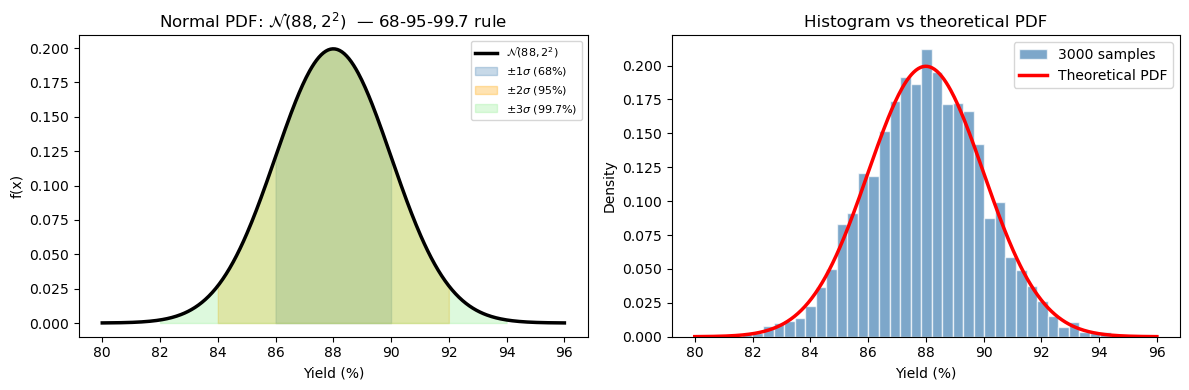

P(yield < 85%)  = 0.0668  (6.68% of batches fail lower limit)
P(yield > 92%)  = 0.0228  (2.28% of batches exceed upper limit)
P(85 ≤ yield ≤ 92%) = 0.9104


In [11]:
# ── Normal distribution ───────────────────────────────────────────────────────
rng  = np.random.default_rng(seed=1)
mu, sigma = 88.0, 2.0          # reactor yield: mean 88%, std 2%

dist_n = stats.norm(loc=mu, scale=sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
samples_n = rng.normal(mu, sigma, 3000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── PDF with shaded regions ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, dist_n.pdf(x), 'k-', linewidth=2.5, label=r'$\mathcal{N}(88, 2^2)$')

# shade ±1σ, ±2σ, ±3σ regions
for k, color, label in [(1, 'steelblue', r'$\pm 1\sigma$ (68%)')  ,
                         (2, 'orange',    r'$\pm 2\sigma$ (95%)')  ,
                         (3, 'lightgreen',r'$\pm 3\sigma$ (99.7%)')]:
    x_fill = np.linspace(mu - k*sigma, mu + k*sigma, 200)
    ax.fill_between(x_fill, dist_n.pdf(x_fill), alpha=0.3, color=color, label=label)

ax.set_xlabel('Yield (%)')
ax.set_ylabel('f(x)')
ax.set_title(r'Normal PDF: $\mathcal{N}(88, 2^2)$  — 68-95-99.7 rule')
ax.legend(fontsize=8)

# ── Histogram of samples vs theoretical PDF ───────────────────────────────────
ax = axes[1]
ax.hist(samples_n, bins=40, density=True, color='steelblue',
        edgecolor='white', alpha=0.7, label='3000 samples')
ax.plot(x, dist_n.pdf(x), 'r-', linewidth=2.5, label='Theoretical PDF')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Density')
ax.set_title('Histogram vs theoretical PDF')
ax.legend()

plt.tight_layout()
plt.show()

# ── Key probabilities ─────────────────────────────────────────────────────────
p_below_85 = dist_n.cdf(85.0)
p_above_92 = 1 - dist_n.cdf(92.0)
print(f"P(yield < 85%)  = {p_below_85:.4f}  ({100*p_below_85:.2f}% of batches fail lower limit)")
print(f"P(yield > 92%)  = {p_above_92:.4f}  ({100*p_above_92:.2f}% of batches exceed upper limit)")
print(f"P(85 ≤ yield ≤ 92%) = {dist_n.cdf(92) - dist_n.cdf(85):.4f}")

### Using the CDF and Percent Point Function (PPF)

Two of the most useful operations on a distribution are asking forward and inverse questions:

**Forward question (CDF):** "Given a value $x$, what fraction of the distribution is below it?"
$$P(X \leq x) = F(x) = \texttt{dist.cdf(x)}$$

**Inverse question (PPF):** "Given a probability $p$, what value has exactly $p \times 100\%$ of the distribution below it?"
$$x = F^{-1}(p) = \texttt{dist.ppf(p)}$$

The PPF (percent point function) is also called the **quantile function** or **inverse CDF**. It is essential for:
- Setting specification limits ("98% of batches should exceed this yield")
- Computing confidence intervals
- Finding critical values in hypothesis tests

| Question | Tool | Formula |
|----------|------|--------|
| $P(X \leq x)$ | `.cdf(x)` | Direct lookup |
| $P(X > x)$ | `1 - .cdf(x)` | Complement (survival) |
| $P(a \leq X \leq b)$ | `.cdf(b) - .cdf(a)` | Difference of CDFs |
| Find $x$ such that $P(X \leq x) = p$ | `.ppf(p)` | Inverse CDF |

In [12]:
# ── CDF / PPF examples ────────────────────────────────────────────────────────
print("Using the Normal distribution  N(88, 2)")
print()
print("CDF — P(X ≤ x):")
for x_val in [84, 86, 88, 90, 92]:
    print(f"  P(yield ≤ {x_val}%) = {dist_n.cdf(x_val):.4f}")

print()
print("PPF — what yield value corresponds to the p-th percentile:")
for p in [0.01, 0.05, 0.10, 0.25, 0.50, 0.90, 0.95, 0.99]:
    print(f"  {int(100*p):>3}th percentile → yield = {dist_n.ppf(p):.2f}%")

Using the Normal distribution  N(88, 2)

CDF — P(X ≤ x):
  P(yield ≤ 84%) = 0.0228
  P(yield ≤ 86%) = 0.1587
  P(yield ≤ 88%) = 0.5000
  P(yield ≤ 90%) = 0.8413
  P(yield ≤ 92%) = 0.9772

PPF — what yield value corresponds to the p-th percentile:
    1th percentile → yield = 83.35%
    5th percentile → yield = 84.71%
   10th percentile → yield = 85.44%
   25th percentile → yield = 86.65%
   50th percentile → yield = 88.00%
   90th percentile → yield = 90.56%
   95th percentile → yield = 91.29%
   99th percentile → yield = 92.65%


(13.4)=
## 13.4 Central Limit Theorem

The **Central Limit Theorem (CLT)** is arguably the most important result in statistics. It explains why the normal distribution appears everywhere and justifies many statistical procedures even when the underlying data is not normally distributed.

> **Statement:** If you draw a sample of size $n$ from *any* distribution with finite mean $\mu$ and variance $\sigma^2$, the sample mean $\bar{X}$ is approximately normally distributed for sufficiently large $n$:
>
> $$\bar{X} \sim \mathcal{N}\!\left(\mu,\; \frac{\sigma^2}{n}\right) \qquad \text{as } n \to \infty$$

Equivalently, the **standardized** sample mean converges to a standard normal:
$$
Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)
$$

### What the CLT tells us step by step

1. **The mean of $\bar{X}$ is $\mu$** — the sample mean is an unbiased estimator of the population mean. Average many measurements and you converge to the true value.

2. **The spread of $\bar{X}$ is $\sigma/\sqrt{n}$** — this is called the **standard error of the mean (SE)**. It shrinks as $1/\sqrt{n}$. To halve the uncertainty in your mean estimate, you need 4× more data.

3. **The shape is normal** — regardless of what the original distribution looks like (uniform, exponential, bimodal, etc.), sample means become bell-shaped.

### Why it matters in ChE

- **Precision of analytical measurements:** If you analyze 5 repeat samples instead of 1, the uncertainty in your mean concentration estimate shrinks by $\sqrt{5} \approx 2.2\times$.
- **Control charts (SPC):** Statistical process control monitors sample means from batches. The CLT justifies using normal-based control limits even if individual measurements are slightly skewed.
- **Confidence intervals:** The $t$-interval (next section) is derived from the CLT — it works because sample means are approximately normal.
- **Propagation of uncertainty:** When a computed quantity is the average of many measurements, its uncertainty is the SE, not the measurement std dev.

### The standard error of the mean

$$
\text{SE} = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}
$$

The SE tells you: "How precisely do I know the population mean, given my sample?" It is always smaller than the sample standard deviation $s$, which describes individual measurement-to-measurement variation.

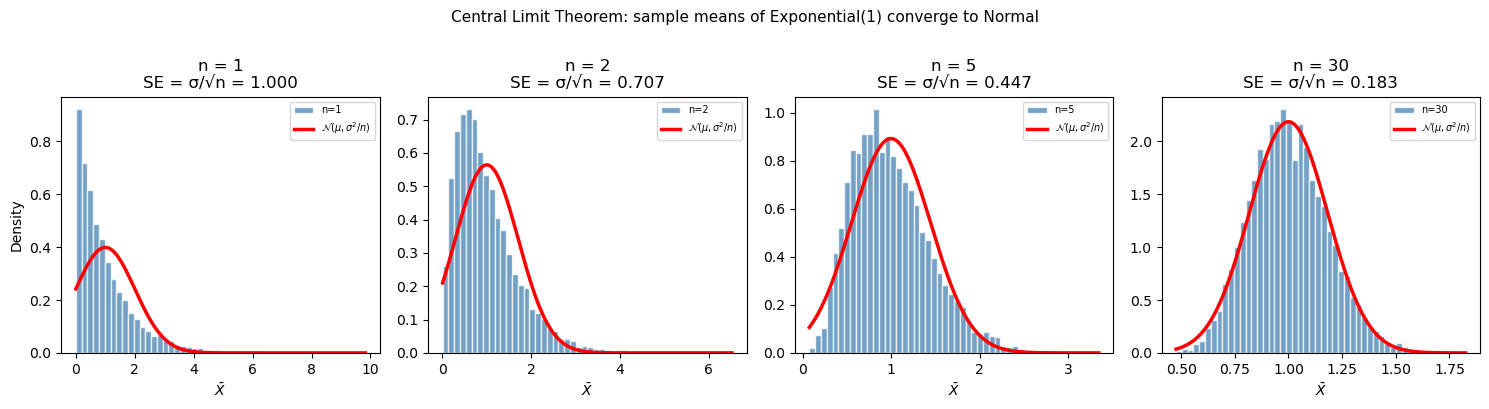

Sample size  |  SE_theory  |  SE_observed
---------------------------------------------
  n =   1     |  1.00000    |  0.99934
  n =   2     |  0.70711    |  0.71129
  n =   5     |  0.44721    |  0.45185
  n =  30     |  0.18257    |  0.18172


In [16]:
# ── Central Limit Theorem demonstration ──────────────────────────────────────
# Start from a very non-normal distribution: exponential(scale=1) → skewed
rng = np.random.default_rng(seed=99)

true_mu    = 1.0      # mean of Exp(1)
true_sigma = 1.0      # std  of Exp(1)
n_simulations = 10_000
sample_sizes  = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4), sharey=False)

for ax, n in zip(axes, sample_sizes):
    # Draw n_simulations samples of size n; compute each sample mean
    data      = rng.exponential(true_mu, size=(n_simulations, n))
    means     = data.mean(axis=1)
    se        = true_sigma / np.sqrt(n)

    ax.hist(means, bins=50, density=True, color='steelblue',
            edgecolor='white', alpha=0.75, label=f'n={n}')

    # Overlay theoretical normal
    x_range = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm(true_mu, se).pdf(x_range),
            'r-', linewidth=2.5, label=r'$\mathcal{N}(\mu,\sigma^2/n)$')

    ax.set_title(f'n = {n}\nSE = σ/√n = {se:.3f}')
    ax.set_xlabel(r'$\bar{X}$')
    ax.set_ylabel('Density' if n == 1 else '')
    ax.legend(fontsize=7)

plt.suptitle('Central Limit Theorem: sample means of Exponential(1) converge to Normal',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("Sample size  |  SE_theory  |  SE_observed")
print("-" * 45)
for n in sample_sizes:
    data  = rng.exponential(true_mu, size=(n_simulations, n))
    means = data.mean(axis=1)
    print(f"  n = {n:>3}     |  {true_sigma/np.sqrt(n):.5f}    |  {np.std(means, ddof=1):.5f}")

(13.5)=
## 13.5 Confidence Intervals

After computing a sample mean $\bar{x}$, we know this is our best estimate of the true population mean $\mu$ — but how good is that estimate? A **confidence interval (CI)** quantifies this uncertainty by giving a range of plausible values for $\mu$.

### What a confidence interval means (carefully)

A 95% CI does **not** mean "there is a 95% probability that $\mu$ is in this interval." The true $\mu$ is a fixed (unknown) number — it is either in the interval or it isn't.

The correct interpretation: **if we repeated the experiment many times and built a 95% CI each time, 95% of those intervals would contain the true mean.** The confidence is in the *procedure*, not in any single interval.

In practice, we say "we are 95% confident the true mean lies in [lo, hi]" — a shorthand for the above.

---

### Step-by-step: How to compute a CI

**Step 1:** Compute the sample mean $\bar{x}$, sample standard deviation $s$, and sample size $n$.

**Step 2:** Compute the **standard error**: $\text{SE} = s/\sqrt{n}$

**Step 3:** Choose a confidence level (90%, 95%, 99%) and find the critical value.

**Step 4:** Compute the **margin of error**: $m = t_{\alpha/2,\, n-1} \times \text{SE}$

**Step 5:** The CI is $[\bar{x} - m,\; \bar{x} + m]$

---

### CI for the mean — known σ (Z-interval)

If the population standard deviation $\sigma$ is known (rare in practice) or $n$ is large ($n \gtrsim 30$):

$$
\bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}}
$$

where $z_{\alpha/2}$ is from the standard normal. Common values: $z_{0.025} = 1.96$ (95% CI), $z_{0.005} = 2.576$ (99% CI).

### CI for the mean — unknown σ (t-interval)

With small samples and unknown $\sigma$ (the usual case in engineering), use the **Student's t-distribution** with $\nu = n - 1$ degrees of freedom:

$$
\bar{x} \pm t_{\alpha/2,\, n-1} \frac{s}{\sqrt{n}}
$$

**Why t instead of z?** When we estimate $\sigma$ from data as $s$, we introduce additional uncertainty — especially for small $n$. The $t$-distribution has heavier tails than the normal, which accounts for this. As $n \to \infty$, $s \to \sigma$ and the $t$-distribution converges to the standard normal.

| $n$ | $t_{0.025,\, n-1}$ (for 95% CI) | Notes |
|----|----------------------------------|-------|
| 5  | 2.776 | Much wider than z! |
| 10 | 2.228 | Still wider |
| 20 | 2.093 | Close to z |
| 30 | 2.045 | Nearly z |
| ∞  | 1.960 (→ z) | Converges |

**ChE practical rule:** Use the $t$-interval for sample sizes up to ~30. Above that, the difference from the $z$-interval is negligible. With small samples ($n < 10$), the $t$-interval can be substantially wider — this is appropriate, because you truly have less information.

In [17]:
# ── Confidence interval for yield data ───────────────────────────────────────
n    = len(yields)
xbar = np.mean(yields)
s    = np.std(yields, ddof=1)
se   = s / np.sqrt(n)

print(f"Sample: n={n}, mean={xbar:.4f}%, s={s:.4f}%, SE={se:.4f}%")
print()

for conf in [0.90, 0.95, 0.99]:
    alpha = 1 - conf
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * se
    lo, hi = xbar - margin, xbar + margin
    print(f"{int(100*conf)}% CI:  [{lo:.4f}, {hi:.4f}]%   (t_crit = {t_crit:.3f}, margin = ±{margin:.4f})")

print()
# scipy convenience function — equivalent result
lo95, hi95 = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
print(f"scipy.stats.t.interval(0.95): [{lo95:.4f}, {hi95:.4f}]%")

Sample: n=15, mean=87.7133%, s=1.8388%, SE=0.4748%

90% CI:  [86.8771, 88.5496]%   (t_crit = 1.761, margin = ±0.8362)
95% CI:  [86.6950, 88.7316]%   (t_crit = 2.145, margin = ±1.0183)
99% CI:  [86.3000, 89.1267]%   (t_crit = 2.977, margin = ±1.4133)

scipy.stats.t.interval(0.95): [86.6950, 88.7316]%


    n      Mean    95% CI width        SE
---------------------------------------------
    5   87.6727          4.8359    0.8709
   10   88.2080          2.8889    0.6385
   20   87.0618          1.3047    0.3117
   50   87.6672          1.0881    0.2707
  100   88.0120          0.7699    0.1940
  200   87.9284          0.5500    0.1395


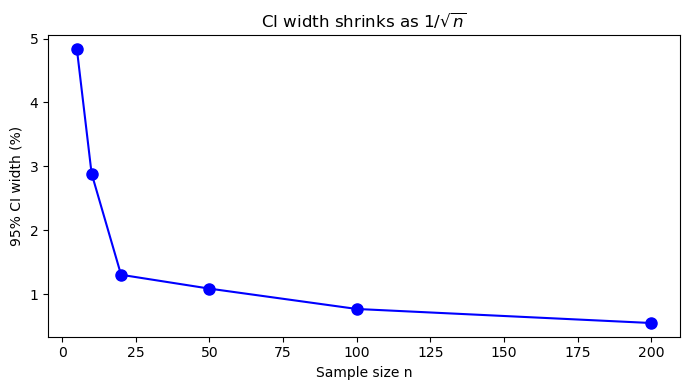

In [18]:
# ── How CI width shrinks with sample size ─────────────────────────────────────
rng   = np.random.default_rng(seed=5)
true_mu, true_sigma = 88.0, 2.0

ns     = [5, 10, 20, 50, 100, 200]
widths = []

print(f"{'n':>5}  {'Mean':>8}  {'95% CI width':>14}  {'SE':>8}")
print("-" * 45)
for n_val in ns:
    sample = rng.normal(true_mu, true_sigma, n_val)
    xb = np.mean(sample)
    se = np.std(sample, ddof=1) / np.sqrt(n_val)
    t  = stats.t.ppf(0.975, df=n_val-1)
    width = 2 * t * se
    widths.append(width)
    print(f"{n_val:>5}  {xb:>8.4f}  {width:>14.4f}  {se:>8.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, widths, 'bo-', markersize=8)
ax.set_xlabel('Sample size n')
ax.set_ylabel('95% CI width (%)')
ax.set_title('CI width shrinks as $1/\\sqrt{n}$')
plt.tight_layout()
plt.show()

### Reading the CI output

From the code above, the 95% CI for the batch yield mean is approximately **[86.7%, 88.7%]**.

**How to interpret this:**
- Our point estimate (sample mean) is 87.71%
- We are 95% confident the *true* long-run mean yield is between 86.7% and 88.7%
- The target is 88.0% — since 88.0% is **inside** the 95% CI, we cannot conclude the process is off-target at the 5% significance level
- With only 15 batches, there is too much uncertainty to be conclusive; we need more data

**Notice the trade-off:** The 99% CI is wider than the 95% CI, which is wider than the 90% CI. More confidence requires a wider interval — this makes intuitive sense.

**Notice the effect of $n$:** The cell below shows that CI width shrinks proportionally to $1/\sqrt{n}$. To cut the CI in half, we need 4× more samples. This guides experimental design: "How many batches do I need to estimate the mean within ±0.5%?"

**Summary**

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Sample mean** | `np.mean(x)` | Center of data |
| **Sample std dev** | `np.std(x, ddof=1)` | Spread of data (always `ddof=1` for samples) |
| **Percentile** | `np.percentile(x, q)` | Quantify tails, IQR |
| **Descriptive summary** | `scipy.stats.describe(x)` | Quick overview incl. skewness, kurtosis |
| **Random generation** | `rng = np.random.default_rng(seed)` | Reproducible random sampling |
| **Normal distribution** | `stats.norm(mu, sigma)` | Measurement errors, process variability |
| **Uniform distribution** | `stats.uniform(loc, scale)` | Bounded uncertainty, no preference |
| **CDF / PPF** | `.cdf(x)` / `.ppf(p)` | Probability below $x$ / value at $p$-th percentile |
| **Central Limit Theorem** | $\bar{X} \sim \mathcal{N}(\mu, \sigma^2/n)$ | Justifies normality of sample means |
| **Confidence interval** | `stats.t.interval(conf, df, loc, scale)` | Range for the true mean |